In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

In [2]:
# 30-39
rcm_past = "../plotting_data/orig_RCM_30-39/id011/*.npy"
emul_past = "../plotting_data/corrdiff/30-39/per_file_id011/*.npy"
emul_past_id21 = "../plotting_data/corrdiff/id20-past/*.npy"
gcm_past = "../plotting_data/GCM/*.npy"
# 90-99
rcm_future = "../plotting_data/orig_RCM/90-99/*.npy"
gcm_future = "../plotting_data/GCM/90-99/*.npy"
emul_future = "../plotting_data/corrdiff/per_file/*.npy"
emul_future_id21 = "../plotting_data/corrdiff/id20-future/*.npy"

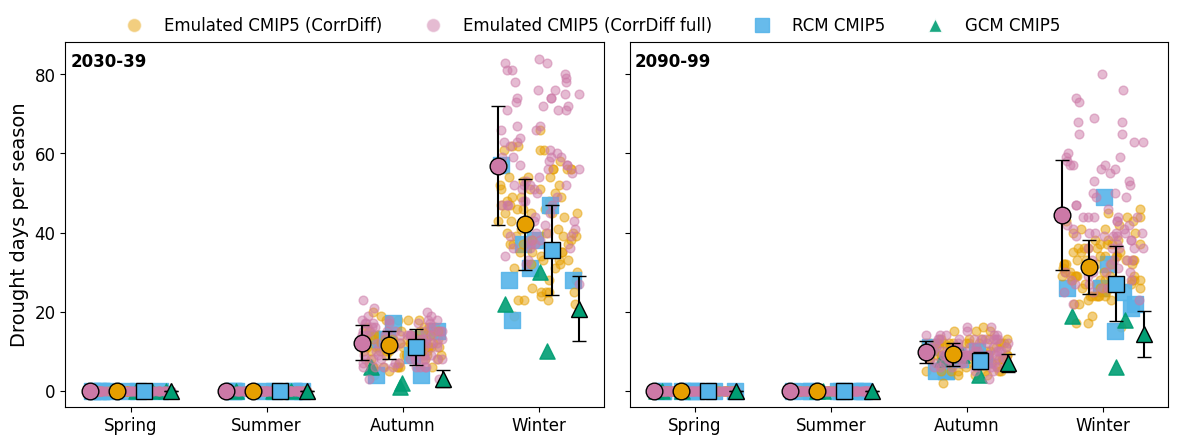

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob

seed = 42
rng = np.random.default_rng(seed)
emul_files = sorted(glob.glob(emul_past))
orig_files = sorted(glob.glob(rcm_past))
gcm_files = sorted(glob.glob(gcm_past))
emul_files_id21 = sorted(glob.glob(emul_past_id21))

emul_files_2 = sorted(glob.glob(emul_future))
orig_files_2 = sorted(glob.glob(rcm_future))
gcm_files_2 = sorted(glob.glob(gcm_future))
emul_files_2_id21 = sorted(glob.glob(emul_future_id21))

emul_color = "#E69F00"
orig_color = "#56B4E9"
gcm_color = "#009E73"
emul_color2 = "#CC79A7"


def plot_co_occurring(ax, emul_files, orig_files, gcm_files, extra_emul_files=None):

    all_emul = []
    all_emul2 = []
    all_orig = []
    all_gcm = []

    new_order = [1, 2, 0, 3]  # reorder seasons

    n_seasons = 4

    # --- Emulated + Original ---
    for i, emul_file in enumerate(emul_files):
        # Emulated
        season_counts = np.load(emul_file, allow_pickle=True)
        if isinstance(season_counts, dict):
            season_counts = list(season_counts.values())[0]
        if season_counts.ndim == 1:
            season_counts = season_counts.reshape(1, -1)
        season_counts = season_counts[:, new_order]  # apply new_order
        all_emul.append(season_counts)
        n_seasons = season_counts.shape[1]
        for e in range(season_counts.shape[0]):
            x = np.arange(n_seasons) + rng.uniform(-0.3, 0.3, size=n_seasons)
            y = season_counts[e, :]
            ax.scatter(x, y, color=emul_color, alpha=0.5, s=40)

        # Original
        orig_counts = np.load(orig_files[i], allow_pickle=True)
        if isinstance(orig_counts, dict):
            orig_counts = list(orig_counts.values())[0]
        if orig_counts.ndim > 1:
            orig_counts = orig_counts[:, new_order]
        else:
            orig_counts = orig_counts[new_order]
        all_orig.append(orig_counts)
        x = np.arange(n_seasons) + rng.uniform(-0.3, 0.3, size=n_seasons)
        ax.scatter(x, orig_counts, color=orig_color, marker="s", s=120, alpha=0.9)

    # --- GCM ---
    for gcm_file in gcm_files:
        gcm_counts = np.load(gcm_file, allow_pickle=True)
        if isinstance(gcm_counts, dict):
            gcm_counts = list(gcm_counts.values())[0]
        if gcm_counts.ndim > 1:
            gcm_counts = gcm_counts[:, new_order]
        else:
            gcm_counts = gcm_counts[new_order]
        all_gcm.append(gcm_counts)
        x = np.arange(n_seasons) + rng.uniform(-0.3, 0.3, size=n_seasons)
        ax.scatter(x, gcm_counts, color=gcm_color, marker="^", s=120, alpha=0.9)

    # --- Extra Emulated (id21) ---
    if extra_emul_files:
        for extra_file in extra_emul_files:
            extra_counts = np.load(extra_file, allow_pickle=True)
            if isinstance(extra_counts, dict):
                extra_counts = list(extra_counts.values())[0]
            if extra_counts.ndim == 1:
                extra_counts = extra_counts.reshape(1, -1)
            extra_counts = extra_counts[:, new_order]
            all_emul2.append(extra_counts)
            for e in range(extra_counts.shape[0]):
                x = np.arange(n_seasons) + rng.uniform(-0.3, 0.3, size=n_seasons)
                y = extra_counts[e, :]
                ax.scatter(x, y, color=emul_color2, alpha=0.5, s=40)

    # --- Compute means/std ---
    emul_mean = np.mean(np.vstack(all_emul), axis=0)
    emul_std = np.std(np.vstack(all_emul), axis=0)
    emul_mean2 = np.mean(np.vstack(all_emul2), axis=0) if all_emul2 else None
    emul_std2 = np.std(np.vstack(all_emul2), axis=0) if all_emul2 else None
    orig_mean = np.mean(np.vstack(all_orig), axis=0)
    orig_std = np.std(np.vstack(all_orig), axis=0)
    gcm_mean = np.mean(np.vstack(all_gcm), axis=0)
    gcm_std = np.std(np.vstack(all_gcm), axis=0)

    x_vals = np.arange(n_seasons)
    offset = 0.1
    ax.errorbar(
        x_vals - 0.1,
        emul_mean,
        yerr=emul_std,
        fmt="o",
        color=emul_color,
        markeredgecolor="black",
        markersize=12,
        capsize=5,
        ecolor="black",
    )
    if emul_mean2 is not None:
        ax.errorbar(
            x_vals - 0.3,
            emul_mean2,
            yerr=emul_std2,
            fmt="o",
            color=emul_color2,
            markeredgecolor="black",
            markersize=12,
            capsize=5,
            ecolor="black",
        )
    ax.errorbar(
        x_vals + 0.1,
        orig_mean,
        yerr=orig_std,
        fmt="s",
        color=orig_color,
        markeredgecolor="black",
        markersize=12,
        capsize=5,
        ecolor="black",
    )
    ax.errorbar(
        x_vals + 0.3,
        gcm_mean,
        yerr=gcm_std,
        fmt="^",
        color=gcm_color,
        markeredgecolor="black",
        markersize=12,
        capsize=5,
        ecolor="black",
    )

    season_names = ["Spring", "Summer", "Autumn", "Winter"]
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(season_names)


# --- Example usage ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].set_ylabel("Drought days per season")

plot_co_occurring(
    axes[0], emul_files, orig_files, gcm_files, extra_emul_files=emul_files_id21
)
plot_co_occurring(
    axes[1], emul_files_2, orig_files_2, gcm_files_2, extra_emul_files=emul_files_2_id21
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color,
        markersize=10,
        alpha=0.5,
        label="Emulated CMIP5 (CorrDiff)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=emul_color2,
        markersize=10,
        alpha=0.5,
        label="Emulated CMIP5 (CorrDiff full)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=orig_color,
        markeredgecolor=orig_color,
        markersize=10,
        alpha=0.9,
        label="RCM CMIP5",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="w",
        markerfacecolor=gcm_color,
        markersize=10,
        alpha=0.9,
        label="GCM CMIP5",
    ),
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
    frameon=False,
)
axes[0].text(
    0.01,
    0.97,
    "2030-39",
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)

axes[1].text(
    0.01,
    0.97,
    "2090-99",
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.savefig("../plots/0077_attention_cmip5.pdf")
plt.show()